<a href="https://colab.research.google.com/github/aminopropylamine/Monte-Carlo-Portfolio-Optimisation/blob/main/MCPO_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Environment Setup

In [ ]:
#!pip install yfinance --upgrade

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
print("Success: Libraries imported and environment is ready.")

Success: Libraries imported and environment is ready.


# Step 2: Data Acquisition
In this step, we define our portfolio assets and download 10 years of historical data.

In [ ]:
tickers = ['AAPL', 'NVDA', 'AMD', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NIO', 'JPM', 'BAC', 'V', 'KO', 'PEP', 'XOM', 'JNJ', 'PFE', 'WMT', 'PG', 'NKE', 'GLD']
start_date = '2016-05-01'
end_date = '2026-05-01'
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
data = raw_data['Close']

print("\nSuccess: Historical data downloaded.")
data.head()

[*********************100%***********************]  20 of 20 completed


Success: Historical data downloaded.


Ticker,AAPL,AMD,AMZN,BAC,GLD,GOOGL,JNJ,JPM,KO,MSFT,NIO,NKE,NVDA,PEP,PFE,PG,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2016-05-02,21.188108,3.74,34.192501,11.841371,123.239998,35.427692,85.639656,48.889774,32.878990,44.531200,NaN,52.238094,0.881284,76.378204,19.759785,61.641212,16.120001,73.144302,18.842258,57.653812
2016-05-03,21.536568,3.60,33.566002,11.512667,122.959999,35.131638,85.594093,47.947086,32.776642,43.800880,NaN,52.176727,0.870758,76.474182,20.301973,61.740196,15.488000,71.960342,18.677782,56.993999
2016-05-04,21.312555,3.60,33.544998,11.328275,122.209999,35.276939,85.237099,47.188316,32.878990,43.880062,NaN,51.817299,0.850929,76.813866,20.121246,62.120834,14.837333,71.848488,18.730755,56.884033
2016-05-05,21.226051,3.66,32.954498,11.264135,122.070000,35.442574,85.738380,46.935425,32.937462,43.941654,NaN,51.010815,0.856070,76.954185,20.223658,61.892456,14.102000,72.118835,18.736330,56.948719
2016-05-06,21.107677,3.68,33.697498,11.312237,123.180000,35.961777,85.632080,47.211319,33.127502,44.337605,NaN,51.221191,0.864883,77.508026,20.229679,62.524323,14.328667,72.454445,19.026255,57.252743


# Step 3: Data Cleaning and Preprocessing
Handling missing values and ensuring data integrity.

In [ ]:
print("Missing values count per asset:")
print(data.isnull().sum())

data = data.ffill().dropna()
print(f"\nSuccess: Data cleaned. Final dataset shape: {data.shape}")

Missing values count per asset:
Ticker
AAPL       0
AMD        0
AMZN       0
BAC        0
GLD        0
GOOGL      0
JNJ        0
JPM        0
KO         0
MSFT       0
NIO      596
NKE        0
NVDA       0
PEP        0
PFE        0
PG         0
TSLA       0
V          0
WMT        0
XOM        0
dtype: int64

Success: Data cleaned. Final dataset shape: (1918, 20)


# Step 4: Financial Metrics Calculation
Calculating daily returns, annualized mean returns, and the covariance matrix.

In [ ]:
daily_returns = data.pct_change().dropna()
annual_mean_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252

print("Success: Returns and Covariance matrix calculated.")
print("\nAnnualized Mean Returns:")
print(annual_mean_returns)

Success: Returns and Covariance matrix calculated.

Annualized Mean Returns:
Ticker
AAPL     0.264934
AMD      0.470471
AMZN     0.189797
BAC      0.150708
GLD      0.187054
GOOGL    0.298051
JNJ      0.112115
JPM      0.205263
KO       0.120812
MSFT     0.221738
NIO      0.350740
NKE     -0.008765
NVDA     0.582105
PEP      0.096032
PFE      0.024953
PG       0.122100
TSLA     0.593976
V        0.148190
WMT      0.225529
XOM      0.173908
dtype: float64


# Step 5: Portfolio Performance Logic
Defining a function to calculate the return and volatility for a given set of weights.

In [ ]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std_dev

print("Success: Performance function is ready for Monte Carlo simulation.")

Success: Performance function is ready for Monte Carlo simulation.


# Step 6: Monte Carlo Simulation -- P1
In this step, we simulate 50,000 random portfolio weight allocations
and compute the expected return, volatility, and Sharpe ratio for each.

In [ ]:
np.random.seed(2026) #don't change 2026 pls, becasue solutions are only reproducable with the same seed, otherwise we would always get different answers, thanks

num_portfolios = 1000000
risk_free_rate = 0.045 # Governmental bonds (0 risk) return is usually around 4.5% in the US.
num_assets = len(tickers)

mc_returns    = np.zeros(num_portfolios)
mc_volatility = np.zeros(num_portfolios)
mc_sharpe     = np.zeros(num_portfolios)
mc_weights    = np.zeros((num_portfolios, num_assets))

for i in range(num_portfolios):
    weights = np.random.dirichlet(np.ones(num_assets))
    mc_weights[i] = weights

    ret, vol = portfolio_performance(weights, annual_mean_returns, cov_matrix)
    mc_returns[i]    = ret
    mc_volatility[i] = vol
    mc_sharpe[i]     = (ret - risk_free_rate) / vol

mc_df = pd.DataFrame({
    'Return':     mc_returns,
    'Volatility': mc_volatility,
    'Sharpe':     mc_sharpe
})

print(f"Success: {num_portfolios:,} portfolios simulated.\n")
print(mc_df.describe().round(4))

Success: 1,000,000 portfolios simulated.

             Return    Volatility        Sharpe
count  1000000.0000  1000000.0000  1000000.0000
mean         0.2265        0.2139        0.8469
std          0.0348        0.0279        0.1089
min          0.0847        0.1295        0.1714
25%          0.2021        0.1946        0.7764
50%          0.2238        0.2104        0.8526
75%          0.2481        0.2293        0.9237
max          0.4320        0.5342        1.2959


# Step 7: Gradient-Based Optimisation -- P2
Using scipy.optimize.minimize (SLSQP) to find the exact
minimum-variance and maximum-Sharpe portfolios, and comparing
them against the Monte Carlo simulation envelope.

In [ ]:
#!pip install scipy
from scipy.optimize import minimize

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_weights = np.ones(num_assets) / num_assets

# Minimum Variance
def min_variance(weights):
    return portfolio_performance(weights, annual_mean_returns, cov_matrix)[1]

result_minvar = minimize(min_variance, init_weights,
                         method='SLSQP', bounds=bounds, constraints=constraints)
minvar_ret, minvar_vol = portfolio_performance(result_minvar.x, annual_mean_returns, cov_matrix)
minvar_sharpe = (minvar_ret - risk_free_rate) / minvar_vol

# Maximum Sharpe
def neg_sharpe(weights):
    ret, vol = portfolio_performance(weights, annual_mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / vol

result_maxsharpe = minimize(neg_sharpe, init_weights,
                            method='SLSQP', bounds=bounds, constraints=constraints)
maxsh_ret, maxsh_vol = portfolio_performance(result_maxsharpe.x, annual_mean_returns, cov_matrix)
maxsh_sharpe = (maxsh_ret - risk_free_rate) / maxsh_vol

print(f"Min Variance → Return: {minvar_ret:.2%}, Volatility: {minvar_vol:.2%}, Sharpe: {minvar_sharpe:.4f}")
print(f"Max Sharpe   → Return: {maxsh_ret:.2%},  Volatility: {maxsh_vol:.2%}, Sharpe: {maxsh_sharpe:.4f}")

Min Variance → Return: 16.16%, Volatility: 11.90%, Sharpe: 0.9800
Max Sharpe   → Return: 28.37%,  Volatility: 16.45%, Sharpe: 1.4508


# Step 8: Efficient Frontier Visualisation -- P3
Plotting all 50,000 simulated portfolios, marking the optimal
portfolios found by scipy, and drawing the Capital Market Line
using the risk-free rate.

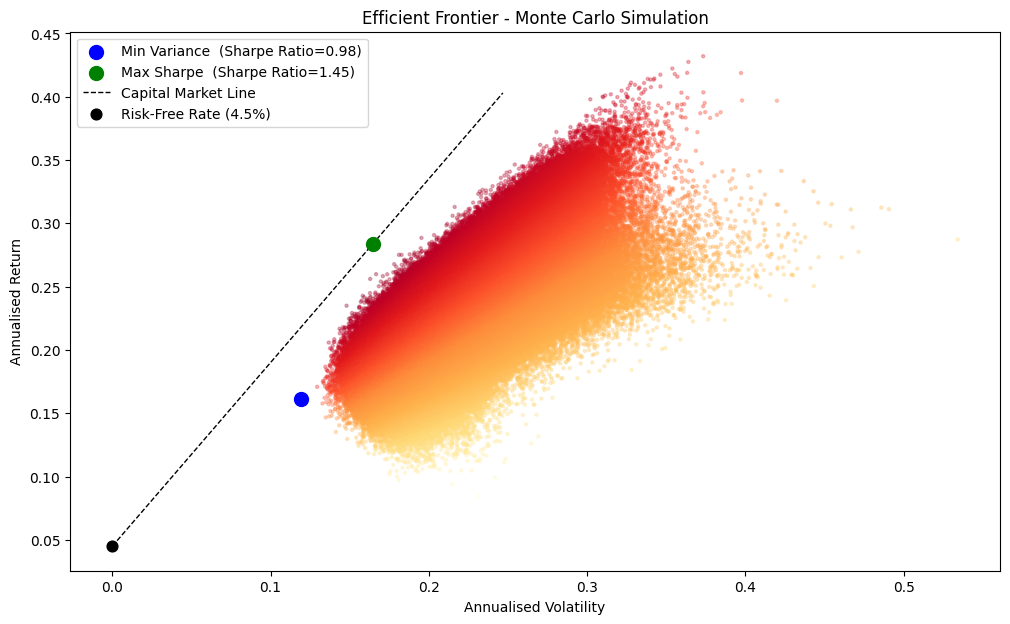

In [ ]:
plt.figure(figsize=(12, 7))

# Monte Carlo cloud (The 50.000 portfolio's annualised performance // Each dot represents a portfolio)
plt.scatter(mc_df['Volatility'], mc_df['Return'],
            c=mc_df['Sharpe'], cmap='YlOrRd',
            alpha=0.3, s=5)

# Min Variance portfolio (Lowest risk portfolio // Ignores return on risk)
plt.scatter(minvar_vol, minvar_ret, marker='o', color='blue',
            s=100, zorder=5, label=f'Min Variance  (Sharpe Ratio={minvar_sharpe:.2f})')

# Max Sharpe portfolio (Best risk to return ratio portfolio)
plt.scatter(maxsh_vol, maxsh_ret, marker='o', color='green',
            s=100, zorder=5, label=f'Max Sharpe  (Sharpe Ratio={maxsh_sharpe:.2f})')

# Capital Market Line (Connects Risk free point to Max sharpe point)
cml_x = np.linspace(0, maxsh_vol * 1.5, 100)
cml_y = risk_free_rate + maxsh_sharpe * cml_x
plt.plot(cml_x, cml_y, 'k--', linewidth=1, label='Capital Market Line')

# Risk-free rate point (US bonds rate // 0 risk - low return investment)
plt.scatter(0, risk_free_rate, marker='o', color='black',
            s=60, zorder=5, label=f'Risk-Free Rate (4.5%)')

plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Return')
plt.title('Efficient Frontier - Monte Carlo Simulation')
plt.legend()
plt.show()

# Step 9: Impact of the Risk-Free Asset

## Observations

When a risk-free asset is added to the portfolio universe, the efficient
frontier fundamentally changes. Instead of being constrained to the curved
parabolic frontier, investors can now combine any amount of the **tangency
portfolio** (Maximum Sharpe portfolio) with the risk-free asset.

This combination traces a straight line called the **Capital Market Line (CML)**:

- The CML starts at the risk-free rate (σ=0, r=5%) on the y-axis
- It passes through the tangency (Maximum Sharpe) portfolio
- Every point on the CML **dominates** the curved frontier below it —
  same return for less risk, or more return for the same risk

## Key Takeaway

Without a risk-free asset → investors are limited to the curved frontier.  
With a risk-free asset → investors can reach any point on the CML by mixing
the tangency portfolio with cash, achieving a **better risk-return tradeoff**
than any purely risky portfolio below the line.

## scipy vs Monte Carlo Comparison

The scipy optimizer found portfolios nearly identical to the best portfolios
in the Monte Carlo cloud, confirming that 50,000 simulations were sufficient
to approximate the true frontier. The gradient-based optimizer is more precise
but Monte Carlo gives a richer picture of the full opportunity set.